In [1]:
import pandas as pd
import seaborn as sns
import folium

# Abre o arquivo .csv e o armazena em um DataFrame
df = pd.read_csv('/content/sample_data/california_housing_train.csv', sep=',')

# Exibe as primeiras linhas do DataFrame
df.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


# Dataset: California Housing

O *California Housing Dataset* é um conjunto de dados frequentemente utilizado em tutoriais de aprendizado de máquina e ciência de dados. Ele contém informações sobre o mercado imobiliário na Califórnia na década de 1990 e é usado para prever o valor médio das casas em diferentes blocos de cidades no estado da Califórnia, com base em diversas características.

## Informações do Dataset

- **Total de Amostras**: 20.640
- **Número de Atributos**: 9

### Atributos
1. **longitude**: A longitude do bloco.
2. **latitude**: A latitude do bloco.
3. **housing_median_age**: A idade mediana das casas no bloco.
4. **total_rooms**: O total de quartos no bloco.
5. **total_bedrooms**: O total de quartos de dormir no bloco.
6. **population**: A população do bloco.
7. **households**: O número de famílias no bloco.
8. **median_income**: A renda mediana das famílias no bloco (escalada).
9. **median_house_value**: O valor médio das casas no bloco (variável alvo).

## Aplicações

Esse dataset é amplamente utilizado para problemas de **regressão** supervisionada, onde o objetivo é prever o valor médio das casas (coluna `median_house_value`) com base nas outras características fornecidas. Ele também é usado para ensinar conceitos como:

- Análise Exploratória de Dados (EDA)
- Treinamento de modelos de regressão
- Avaliação de performance de modelos
- Feature Engineering

In [2]:
# prompt: Usando o DataFrame df: Escreva o número de linhas e colunas do dataframe

# Obtém o número de linhas e colunas
num_rows = df.shape[0]
num_cols = df.shape[1]

# Exibe o número de linhas e colunas
print(f"Número de linhas: {num_rows}")
print(f"Número de colunas: {num_cols}")


Número de linhas: 17000
Número de colunas: 9


## Qual é a renda média (`median_income`) das famílias no dataset?



In [3]:
# prompt: Qual é a renda média (median_income) das famílias no dataset?

median_income_mean = df['median_income'].mean()
print(f"A renda média das famílias no dataset é: {median_income_mean}")

median_income_median = df['median_income'].median()
print(f"A mediana da renda média das famílias no dataset é: {median_income_median}")

median_income_max = df['median_income'].max()
print(f"O valor máximo da renda média das famílias no dataset é: {median_income_max}")

median_income_min = df['median_income'].min()
print(f"O valor mínimo da renda média das famílias no dataset é: {median_income_min}")

A renda média das famílias no dataset é: 3.8835781000000007
A mediana da renda média das famílias no dataset é: 3.5446
O valor máximo da renda média das famílias no dataset é: 15.0001
O valor mínimo da renda média das famílias no dataset é: 0.4999


In [4]:
# prompt: Calcule os quartis para a variável median_income.

# Calcula os quartis para a variável median_income
quartis_median_income = df['median_income'].quantile([0.25, 0.5, 0.75])

print(f"Os quartis para a variável median_income são:\n{quartis_median_income}")

Os quartis para a variável median_income são:
0.25    2.566375
0.50    3.544600
0.75    4.767000
Name: median_income, dtype: float64


<Axes: >

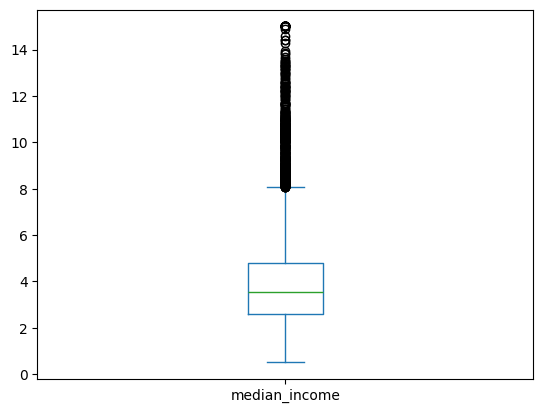

In [5]:
df['median_income'].plot(kind='box')

### Qual é a idade média (`housing_median_age`) das casas?

In [6]:
# prompt: Qual é a idade média (housing_median_age) das casas?

housing_median_age_mean = df['housing_median_age'].mean()
print(f"A idade média das casas é: {housing_median_age_mean}")


A idade média das casas é: 28.58935294117647


### Qual a correlação entre a renda média (`median_income`) e o valor médio das casas (`median_house_value`)?

In [ ]:
# prompt: Qual a correlação entre a renda média (median_income) e o valor médio das casas (`median_house_value)?

correlation = df['median_income'].corr(df['median_house_value'])
print(f"A correlação entre a renda média e o valor médio das casas é: {correlation}")


A correlação entre a renda média e o valor médio das casas é: 0.6918706037806693


In [ ]:

correlation = df['longitude'].corr(df['median_house_value'])
print(f"A correlação entre a longitude e o valor médio das casas é: {correlation}")


A correlação entre a longitude e o valor médio das casas é: -0.04498169651091465


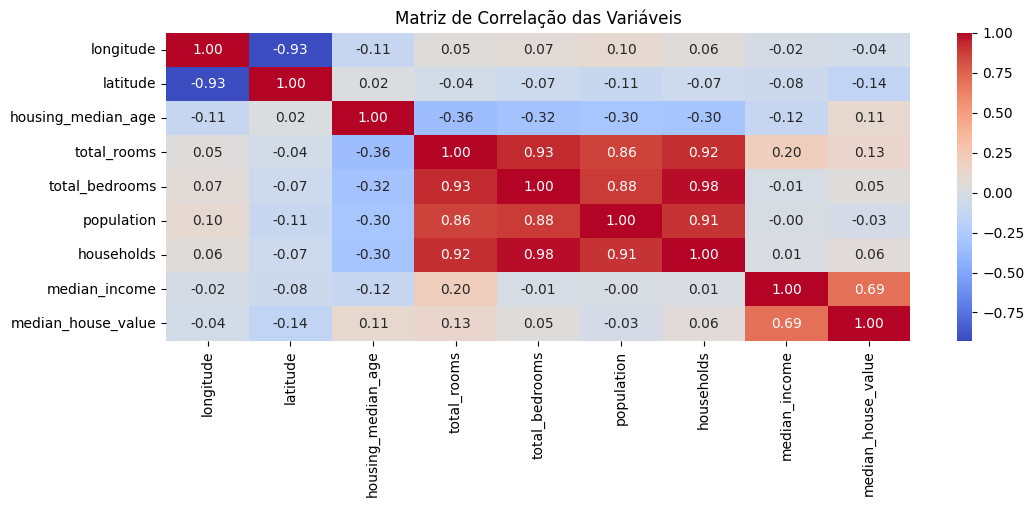

In [ ]:
# prompt: Quero um mapa de calor para mostrar as correlações de todas as variáveis do dataset.

import matplotlib.pyplot as plt

# Calcula a matriz de correlação
correlation_matrix = df.corr()

# Plota o mapa de calor
plt.figure(figsize=(12, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis')
plt.show()


### Como é distribuído o valor médio das casas (`median_house_value`) nas diferentes localizações geográficas (`latitude e longitude`)?

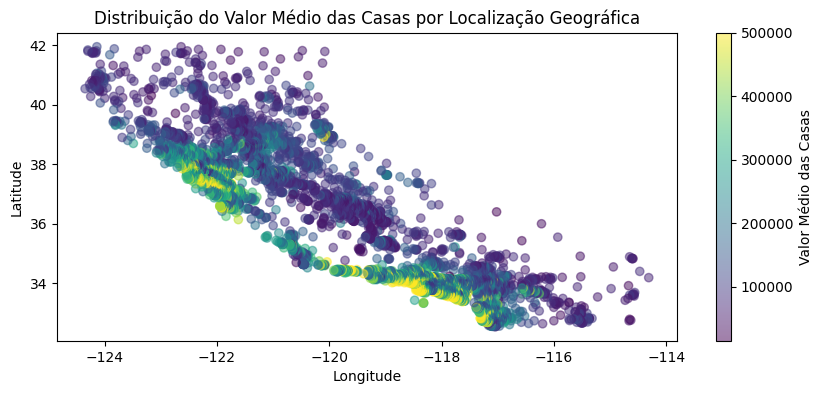

In [ ]:
# prompt: Como é distribuído o valor médio das casas (median_house_value) nas diferentes localizações geográficas (latitude e longitude)?

import matplotlib.pyplot as plt

# Criando um scatter plot para visualizar a distribuição do valor médio das casas em relação à latitude e longitude
plt.figure(figsize=(10, 4))
plt.scatter(df['longitude'], df['latitude'], c=df['median_house_value'], cmap='viridis', alpha=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Valor Médio das Casas')
plt.title('Distribuição do Valor Médio das Casas por Localização Geográfica')
plt.show()


### Como a população (`population`) se distribui em relação ao número de famílias (`households`) no dataset?

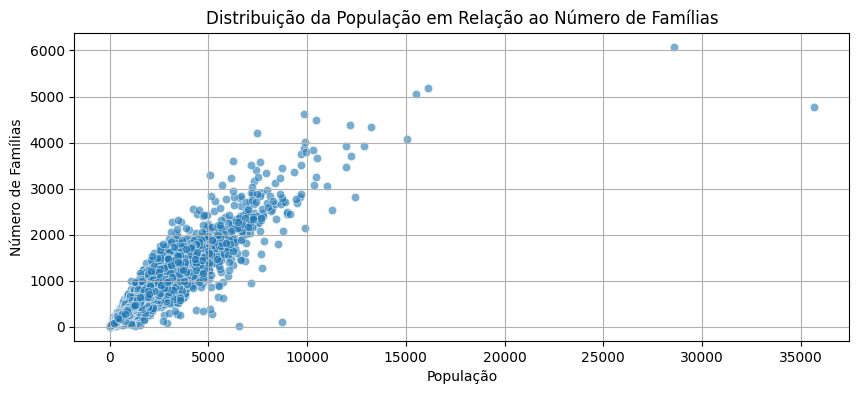

In [ ]:
plt.figure(figsize=(10, 4))
sns.scatterplot(x='population', y='households', data=df, alpha=0.6)
plt.title('Distribuição da População em Relação ao Número de Famílias')
plt.xlabel('População')
plt.ylabel('Número de Famílias')
plt.grid(True)
plt.show()

In [ ]:
# Criar o mapa centrado na Califórnia
m = folium.Map(location=[37.0, -120.0], zoom_start=6)

# Adicionar os pontos ao mapa
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,  # Tamanho do ponto
        popup=f"Valor Médio: ${row['median_house_value']}\n Latitude: {row['latitude']}, Longitude: {row['longitude']}",  # Informações ao clicar
        color='blue',  # Cor do círculo
        fill=True,
        fill_color='lightblue'
    ).add_to(m)

# Exibir o mapa
m

KeyboardInterrupt: 

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


## 📊 Escolher uma variável explicativa

In [ ]:
X_train = df[['longitude']]  # variável independente (renda média das famílias)
y_train = df['median_house_value']  # variável dependente (valor médio das casas)

## 📈 Visualizar a relação entre as variáveis

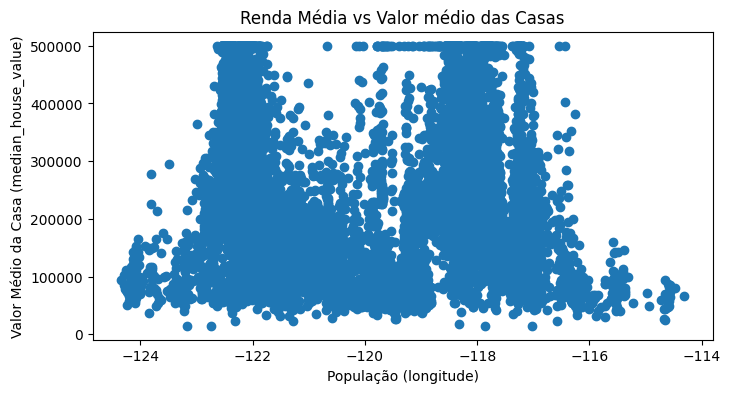

In [ ]:
plt.figure(figsize=(8, 4))
plt.scatter(X_train, y_train)
plt.xlabel("População (longitude)")
plt.ylabel("Valor Médio da Casa (median_house_value)")
plt.title("Renda Média vs Valor médio das Casas")
plt.show()

## 🤖 Treinar o modelo de regressão linear

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Coeficiente (slope):", model.coef_[0])
print("Intercepto:", model.intercept_)

Coeficiente (slope): -2601.852129546547
Intercepto: -103782.01357213355


## 🧮 Fazer previsões e visualizar a reta

In [ ]:
# Abre o arquivo .csv e o armazena em um DataFrame
df_test = pd.read_csv('/content/sample_data/california_housing_test.csv', sep=',')

In [ ]:
df_test.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


In [ ]:
df_test.shape

(3000, 9)

In [ ]:
# Previsões
X_test = df_test[['longitude']]
y_test = df_test['median_house_value']
y_pred = model.predict(X_test)

In [ ]:
y_test[0:5]

,median_house_value
0,344700.0
1,176500.0
2,270500.0
3,330000.0
4,81700.0


In [ ]:
y_pred[0:5]

array([213774.03883902, 204017.09335322, 202742.18580975, 204173.204481  ,
       207581.6307707 ])

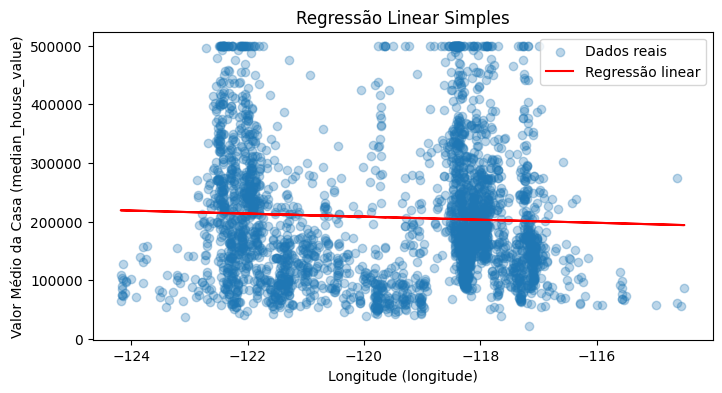

In [ ]:
# Visualizando a linha de regressão
plt.figure(figsize=(8, 4))
plt.scatter(X_test, y_test, alpha=0.3, label='Dados reais')
plt.plot(X_test, y_pred, color='red', label='Regressão linear')
plt.xlabel("Longitude (longitude)")
plt.ylabel("Valor Médio da Casa (median_house_value)")
plt.title("Regressão Linear Simples")
plt.legend()
plt.show()

## 📏 Avaliação do modelo

### Mean Squared Error (Erro Quadrático Médio)

\begin{equation}
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
\end{equation}

Onde:

\begin{equation}
\begin{aligned}
 &\bullet y_i \quad\text{= }  \text{valor real da observação} \\
 &\bullet \hat{y}_i \quad\text{= } \text{valor previsto pelo modelo} \\
 &\bullet n \quad\text{= } \text{número total de observações} \\
\end{aligned}
\end{equation}

✅ O que é:
* É a média dos quadrados dos erros (diferença entre o valor real e o valor previsto).

* Ele está na mesma unidade do valor da variável dependente ao quadrado, então neste caso, o MSE está na ordem de milhões ao quadrado (porque o median_house_value é dado em centenas de milhares de dólares).

* Um MSE muito alto indica que as previsões estão, em média, longe dos valores reais.

* Como usamos apenas uma variável (median_income) para prever o valor da casa, é natural que o modelo não consiga capturar todos os fatores que influenciam esse valor (número de quartos, localização, idade da casa, etc.).

* Ou seja, o modelo está errando bastante em valores absolutos, mas isso é esperado em uma regressão simples.

### R² – Coeficiente de Determinação

\begin{equation}
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
\end{equation}

Onde:

\begin{equation}
\begin{aligned}
  &\bullet \bar{y} \quad\text{= } \text{média dos valores reais} \\
  &\bullet y_i \quad\text{= } \text{valor real da observação} \\
  &\bullet \hat{y}_i \quad\text{= } \text{o valor previsto pelo modelo} \\
  &\bullet n \quad\text{= } \text{número total de observações} \\
\end{aligned}
\end{equation}

✅ O que é:
* Mede quanto da variação dos dados o modelo conseguiu explicar.

* Vai de 0 (modelo não explica nada) até 1 (modelo explica tudo).

* O valor 0.452 indica que 45,2% da variação do valor das casas é explicada pela renda média da região.

* Isso já é um bom resultado para um modelo simples, considerando que usamos apenas uma variável explicativa.

* Também mostra que existem outros fatores importantes além da renda que precisam ser considerados para melhorar o modelo (o que justifica o uso de regressão múltipla depois).

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 12761584077.0494
R²: 0.002362002653317985


In [ ]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

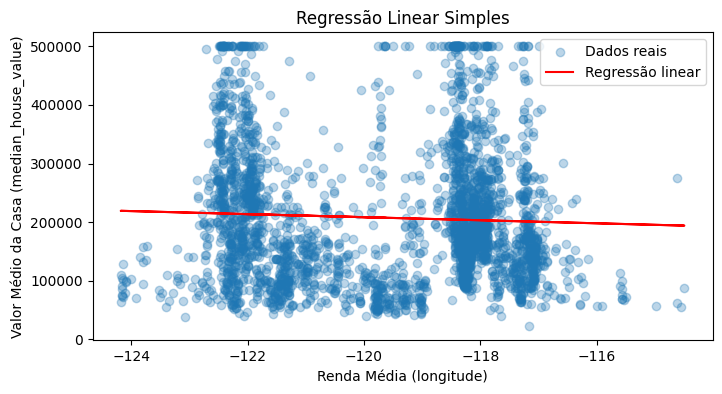

In [ ]:
plt.figure(figsize=(8, 4))
plt.scatter(X_test, y_test, alpha=0.3, label='Dados reais')
plt.plot(X_test, y_pred, color='red', label='Regressão linear')
plt.xlabel("Renda Média (longitude)")
plt.ylabel("Valor Médio da Casa (median_house_value)")
plt.title("Regressão Linear Simples")
plt.legend()
plt.show()

# 🧪 Atividade: Comparando Regressões Lineares Simples

🎯 **Objetivo**

Nesta atividade, vamos aprofundar o uso da **regressão linear simples** explorando diferentes variáveis independentes (features) do dataset **California Housing**. A ideia é investigar qual variável tem maior poder preditivo sobre o valor médio das casas (`median_house_value`), usando métricas de avaliação como **MSE** e **R²**.

📌 **Instruções**

1. Escolha outras variáveis independentes do dataset California Housing, além de `median_income`, por exemplo:

  * **longitude**: A longitude do bloco.
  * **latitude**: A latitude do bloco.
  * **housing_median_age**: A idade mediana das casas no bloco.
  * **total_rooms**: O total de quartos no bloco.
  * **total_bedrooms**: O total de quartos de dormir no bloco.
  * **population**: A população do bloco.
  * **households**: O número de famílias no bloco.

2. Para cada variável escolhida, crie um modelo de regressão linear simples com `median_house_value` como variável dependente.

3. Calcule as métricas de avaliação para cada modelo no **conjunto de teste**:

  * MSE (Mean Squared Error)
  * R² (Coeficiente de Determinação)

4. Crie uma tabela comparativa com os resultados obtidos para cada variável explicativa. A tabela deve conter:

<div align="center">

| Variável Independente | MSE           | R²     |
|-----------------------|---------------|--------|
| longitude             |               |        |
| latitude              |               |        |
| housing_median_age    |               |        |
| total_rooms           |               |        |
| total_bedrooms        |               |        |
| population            |               |        |
| median_income         |               |        |

</div>

5. Analise os resultados:

  * Qual variável foi mais eficiente na previsão do valor da casa?
  * Alguma variável teve desempenho muito baixo?
  * Os valores de R² são altos ou baixos? O que isso diz sobre o poder preditivo da variável?

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Lista das variáveis independentes
variaveis = [
    'longitude',
    'latitude',
    'housing_median_age',
    'total_rooms',
    'total_bedrooms',
    'population',
    'households',
    'median_income'
]

resultados = []

# Loop pelas variáveis
for var in variaveis:
    X = df[[var]]

    # Reaproveita os índices do split anterior
    X_train_var = X.loc[X_train.index]
    X_test_var = X.loc[X_test.index]

    modelo = LinearRegression()
    modelo.fit(X_train_var, y_train)

    y_pred = modelo.predict(X_test_var)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n🔹 Variável: {var}")
    print(f"   - MSE: {mse:.2f}")
    print(f"   - R²: {r2:.4f}")

    resultados.append({
        'Variável Independente': var,
        'MSE': mse,
        'R²': r2
    })

# Exibe a tabela final
df_resultados = pd.DataFrame(resultados)
print("\n📊 Tabela Comparativa Final:")
print(df_resultados.sort_values(by='R²', ascending=False).reset_index(drop=True))



🔹 Variável: longitude
   - MSE: 12811411107.80
   - R²: -0.0015

🔹 Variável: latitude
   - MSE: 13189954449.60
   - R²: -0.0311

🔹 Variável: housing_median_age
   - MSE: 12975432766.56
   - R²: -0.0144

🔹 Variável: total_rooms
   - MSE: 13361422514.20
   - R²: -0.0445

🔹 Variável: total_bedrooms
   - MSE: 12882229991.04
   - R²: -0.0071

🔹 Variável: population
   - MSE: 12781157388.19
   - R²: 0.0008

🔹 Variável: households
   - MSE: 12932479134.80
   - R²: -0.0110

🔹 Variável: median_income
   - MSE: 18459675506.78
   - R²: -0.4431

📊 Tabela Comparativa Final:
  Variável Independente           MSE        R²
0            population  1.278116e+10  0.000832
1             longitude  1.281141e+10 -0.001533
2        total_bedrooms  1.288223e+10 -0.007070
3            households  1.293248e+10 -0.010998
4    housing_median_age  1.297543e+10 -0.014356
5              latitude  1.318995e+10 -0.031126
6           total_rooms  1.336142e+10 -0.044530
7         median_income  1.845968e+10 -0.443087

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# ?? Carregar o dataset
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

# ?? Lista de variáveis independentes
variaveis = [
    'longitude',
    'housing_median_age',
    'total_rooms',
    'total_bedrooms',
    'population',
    'households',
    'median_income'
]

variaveis

['longitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income']

In [ ]:
# ?? Tabela de resultados
resultados = []
#Para cada variável escolhida, crie um modelo de regressão linear simples com median_house_value como variável dependente

# ?? Para cada variável, aplicar regressão linear simples
for var in variaveis:
    X = df[[var]]
    y = df['median_house_value']

    # Dividir treino/teste
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Criar e treinar o modelo
    modelo = LinearRegression()
    modelo.fit(X_train, y_train)

    # Fazer previsões
    y_pred = modelo.predict(X_test)

    # Calcular métricas
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Armazenar resultados
    resultados.append({
        'Variável Independente': var,
        'MSE': mse,
        'R²': r2
    })


In [ ]:
df_resultados = pd.DataFrame(resultados)
print("\n?? Tabela Comparativa Final:")
print(df_resultados.sort_values(by='R²', ascending=False).reset_index(drop=True))



?? Tabela Comparativa Final:
  Variável Independente           MSE        R²
0         median_income  6.920028e+09  0.497779
1           total_rooms  1.350457e+10  0.019906
2    housing_median_age  1.362963e+10  0.010830
3            households  1.372879e+10  0.003633
4        total_bedrooms  1.374932e+10  0.002143
5             longitude  1.376950e+10  0.000679
6            population  1.377967e+10 -0.000060


In [ ]:
melhor = df_resultados.sort_values(by='R²', ascending=False).iloc[0]
piores = df_resultados[df_resultados['R²'] < 0.1]

print("\n?? Análise dos Resultados:")
print(f"- Variável com melhor desempenho: **{melhor['Variável Independente']}** (R² = {melhor['R²']:.4f})")
if not piores.empty:
    print(f"- Variáveis com desempenho muito baixo (R² < 0.1): {', '.join(piores['Variável Independente'])}")
else:
    print("- Nenhuma variável teve R² extremamente baixo.")
print("- Valores baixos de R² indicam que variáveis isoladas explicam pouco o valor das casas.")



?? Análise dos Resultados:
- Variável com melhor desempenho: **median_income** (R² = 0.4978)
- Variáveis com desempenho muito baixo (R² < 0.1): longitude, housing_median_age, total_rooms, total_bedrooms, population, households
- Valores baixos de R² indicam que variáveis isoladas explicam pouco o valor das casas.
